# Related Q/Discussion

1. Why grad descent when there is analytical solution?
    ```
    When you use the normal equations for solving the cost function analytically you have to compute all matrices.

    Where X is your matrix of input observations and y your output vector. The problem with this operation is the time complexity of calculating the inverse of a nxn matrix which is O(n^3) and as n increases it can take a very long time to finish.

    When n is low (n < 1000 or n < 10000) you can think of normal equations as the better option for calculation theta, however for greater values Gradient Descent is much more faster, so the only reason is the time :)
    ```

Base Solution

In [7]:
import numpy as np

np.random.seed(42)

class LinearRegression:
    def __init__(self, n_iters=50,lr =1e-3 ):
        self.n_iters = n_iters
        self.lr = lr
        self.weights = None
        self.bias = None
    
    def fit(self,X,y):
        n_samples, n_features = X.shape
        self.weights = np.random.randn(n_features)
        self.bias = 0

        for i in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias
            # The gradient for linear regression is:
            # For weights:
            # grad_w = (2/n) * X.T @ (y_pred - y)
            # For bias:
            # grad_b = (2/n) * np.sum(y_pred - y)
            # This comes from differentiating the MSE loss:
            # (1/n) * sum((y_pred - y)^2) with respect to weights and bias.
            dw = (2/n_samples) * np.dot(X.T, (y_pred-y))
            db = (2/n_samples) * np.sum(y_pred-y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [9]:
# Generate random data that roughly follows a linear trend with noise
np.random.seed(42)
X = np.random.uniform(0, 25, 60).reshape(-1, 1)  # 60 random X values between 0 and 25
true_slope = 1.8
true_intercept = 3.5
noise = np.random.normal(0, 6, size=X.shape[0])  # larger noise for more randomness
y = true_slope * X.flatten() + true_intercept + noise  # linear plus noise

# initialize linear regression model
linreg = LinearRegression(n_iters=1000, lr=0.001)

# train model on sample dataset
linreg.fit(X, y)

# make predictions on new data
X_new = np.random.uniform(0, 25, 3).reshape(-1, 1)
y_pred = linreg.predict(X_new)

print("Predictions for X_new:", y_pred)


Predictions for X_new: [25.74940725 34.23069889 18.60628325]


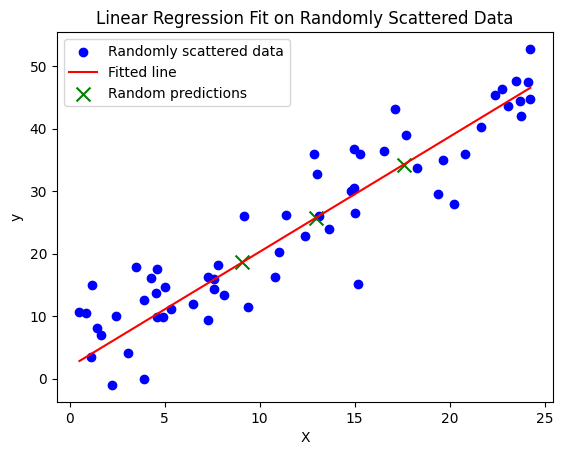

In [10]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue', label='Randomly scattered data')
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = linreg.predict(X_line)
plt.plot(X_line, y_line, color='red', label='Fitted line')
plt.scatter(X_new, y_pred, color='green', marker='x', s=100, label='Random predictions')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Linear Regression Fit on Randomly Scattered Data")
plt.show()